Die benötigten Imports:

In [126]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import cv2


# Hausaufgabe Woche 1 - Intro and Basics

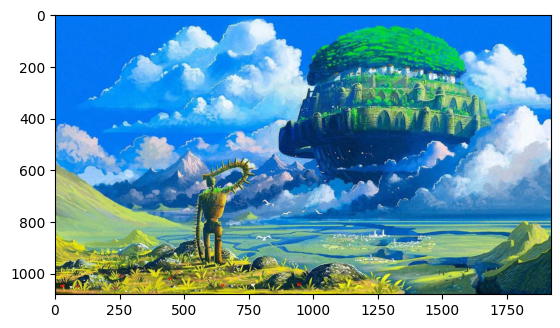

In [127]:
img = cv2.imread("images/ghibli.jpg") # Bild einlesen im BGR Format
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # in RGB Format konvertiert

plt.imshow(img)


Das Bild wurde richtig eingelesen und nach Konvertierung ins RGB Format korrekt mithilfe von Matplotlib ausgegeben. <br><br>

Im nächsten Schritt wird die Bildauflösung ermittelt.  
Dazu werden zunächst die Anzahl der Pixel in y-Richtung (Höhe) und in x-Richtung (Breite) ausgelesen und in den Variablen `height_px` und `width_px` gespeichert.  
Diese Werte geben an, wie viele einzelne Bildpunkte das Bild entlang der jeweiligen Achse enthält.

In [128]:
height_px, width_px, channel = img.shape # Anzahl der Farbkanäle werden ebenfalls ausgelesen

# prints für eine Ordentliche Übersicht in der Konsole:
print(f"Anzahl der Pixel in x Richtung: {width_px}")
print(f"Anzahl der Pixel in y Richtung: {height_px}")
print (f"Gesamtanzahl der Pixel: {width_px * height_px}") # Pixel in x Richtung * Pixel in y Richtung = Gesamtpixelanzahl
print(f"Anzahl der Farbkanäle: {channel}")

Anzahl der Pixel in x Richtung: 1920
Anzahl der Pixel in y Richtung: 1080
Gesamtanzahl der Pixel: 2073600
Anzahl der Farbkanäle: 3


Die ermittelte Bildauflösung beträgt 1920 × 1080 Pixel, was einer Gesamtzahl von etwa 2,07 Millionen Pixeln entspricht.
Damit handelt es sich um eine Full-HD-Auflösung. <br><br>

Im nächsten Schritt wird der obere rechte Quadrant des Bildes extrahiert und als neues Teilbild gespeichert.
Dieser Ausschnitt wird anschließend separat visualisiert, um eine genauere Analyse des entsprechenden Bildbereichs zu ermöglichen.

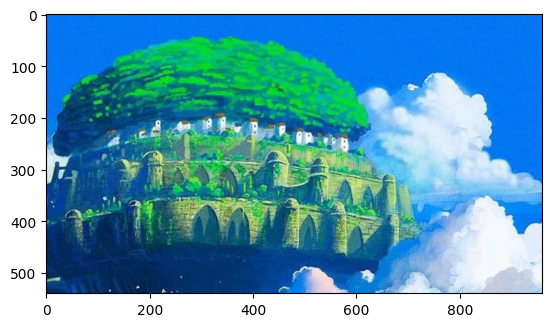

In [129]:
height_half = height_px // 2 # Ganzzahldivision
width_half = width_px // 2 # Ganzzahldivision

#image slicen auf oberen rechten Quadranten
img_quarter = img[0:height_half, width_half:width_px] # oberer Rechter Quadrant

plt.imshow(img_quarter)

Beim Arbeiten mit digitalen Bildern ist zu beachten, dass das Koordinatensystem der Pixelmatrix nicht dem klassischen mathematischen Koordinatensystem entspricht.  
In der Computerbildverarbeitung liegt der Ursprung (0, 0) standardmäßig oben links im Bild.

Zunächst wird mithilfe einer Ganzzahldivision (`//`) die Bildmitte in x- und y-Richtung berechnet, um halbe Pixelwerte zu vermeiden.  
Anschließend wird aus den Bilddaten der obere rechte Quadrant über Array-Slicing extrahiert.  
Dabei ist zu berücksichtigen, dass der Ursprung des Koordinatensystems oben links liegt. Somit entsprechen kleinere y-Werte den oberen Bildbereichen.  
Der extrahierte Quadrant wird anschließend erfolgreich visualisiert.

<br>
In diesem Abschnitt werden die einzelnen Farbkanäle (Rot, Grün, Blau) des Bildausschnitts extrahiert und separat vorbereitet, um sie später einzeln darstellen zu können.
Zunächst werden die RGB-Kanäle aus dem ursprünglichen Bild gesliced, sodass jeweils nur die Intensitätswerte des jeweiligen Farbanteils erhalten bleiben.

Da jedes Kanalbild weiterhin im dreidimensionalen RGB-Format vorliegen muss, werden die nicht benötigten Farbkanäle auf Null gesetzt.
So bleibt die Struktur für plt.imshow() erhalten, und jeder Farbkanal kann als eigenes RGB-Bild korrekt visualisiert werden.

In [130]:
# Slicen der einzelnen Farbanteile aus dem Bildausschnitt
R = img_quarter[:, :, 0]  # Rotanteil der Bildpixel
G = img_quarter[:, :, 1]  # Grünanteil der Bildpixel
B = img_quarter[:, :, 2]  # Blauanteil der Bildpixel

# Leere Arrays im RGB-Format erzeugen (alle Werte 0, schwarzer Hintergrund)
R_display = np.ones_like(img_quarter)
G_display = np.ones_like(img_quarter)
B_display = np.ones_like(img_quarter)

# Nur den jeweiligen Farbkanal belegen, um das RGB-Format beizubehalten
R_display[:, :, 0] = R  # Rotkanal aktiv, Grün & Blau = 0
G_display[:, :, 1] = G  # Grünkanal aktiv, Rot & Blau = 0
B_display[:, :, 2] = B  # Blaukanal aktiv, Rot & Grün = 0



Durch die zuvor erstellten RGB-Teilbilder der einzelnen Farbkanäle (Rot, Grün und Blau) können diese nun gemeinsam in einer Abbildung mit drei Teilplots dargestellt werden.
So lässt sich der Beitrag jedes Kanals zur Gesamtfarbkomposition des Bildes direkt vergleichen.
Zur besseren Übersicht werden die Achsenbeschriftungen ausgeblendet, sodass der Fokus vollständig auf den Bildinhalten liegt.

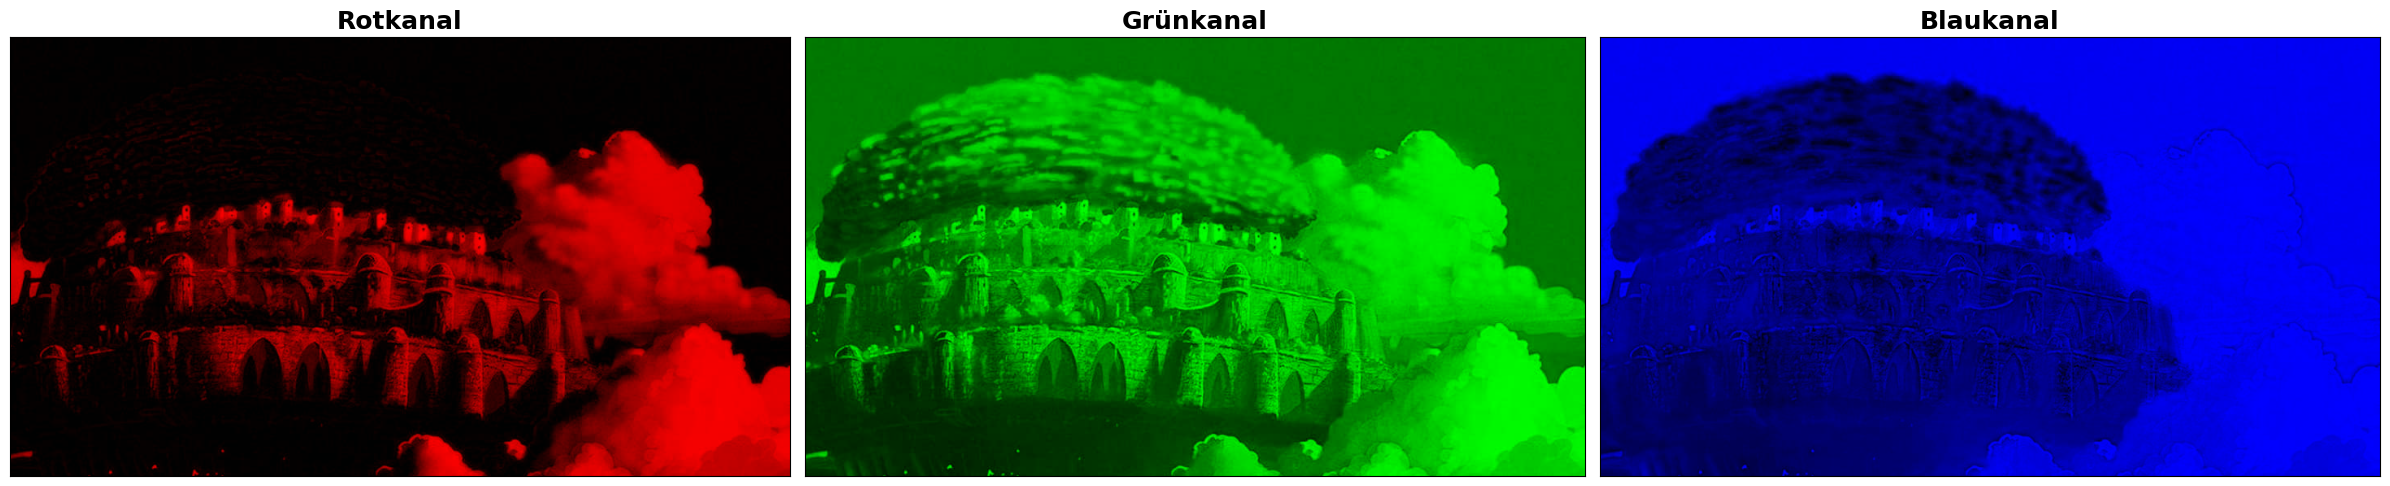

In [131]:

fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # alle Bilder in eine figure nebeneinander

axes[0].imshow(R_display)
axes[0].set_title("Rotkanal", fontsize=18, fontweight="bold")

axes[1].imshow(G_display)
axes[1].set_title("Grünkanal", fontsize=18, fontweight="bold")

axes[2].imshow(B_display)
axes[2].set_title("Blaukanal", fontsize=18, fontweight="bold")

# Axenbeschriftung ausblenden
for ax in axes:
    ax.set_xticks([])  # x-Achsen-Beschriftung aus
    ax.set_yticks([])  # y-Achsen-Beschriftung aus

plt.tight_layout()
plt.show()


Es ist zu erkennen, dass die einzelnen Farbkanäle jeweils ausschließlich ihre entsprechende Farbe darstellen.
Bildbereiche, in denen kein Anteil dieser Farbe vorhanden ist, erscheinen schwarz, da die übrigen Kanäle zuvor auf 0 gesetzt wurden.

Alternativ kann anstelle des RGB-Formats der Parameter `cmap` in der Funktion `imshow()` verwendet werden.  
Mit diesem Parameter lässt sich eine Colormap (z. B. `"Reds"`, `"Greens"` oder `"Blues"`) auf ein zweidimensionales Array anwenden, wodurch eine farblich eingefärbte Darstellung des jeweiligen Farbkanals möglich ist, ohne zuvor die RGB-Struktur rekonstruieren zu müssen.

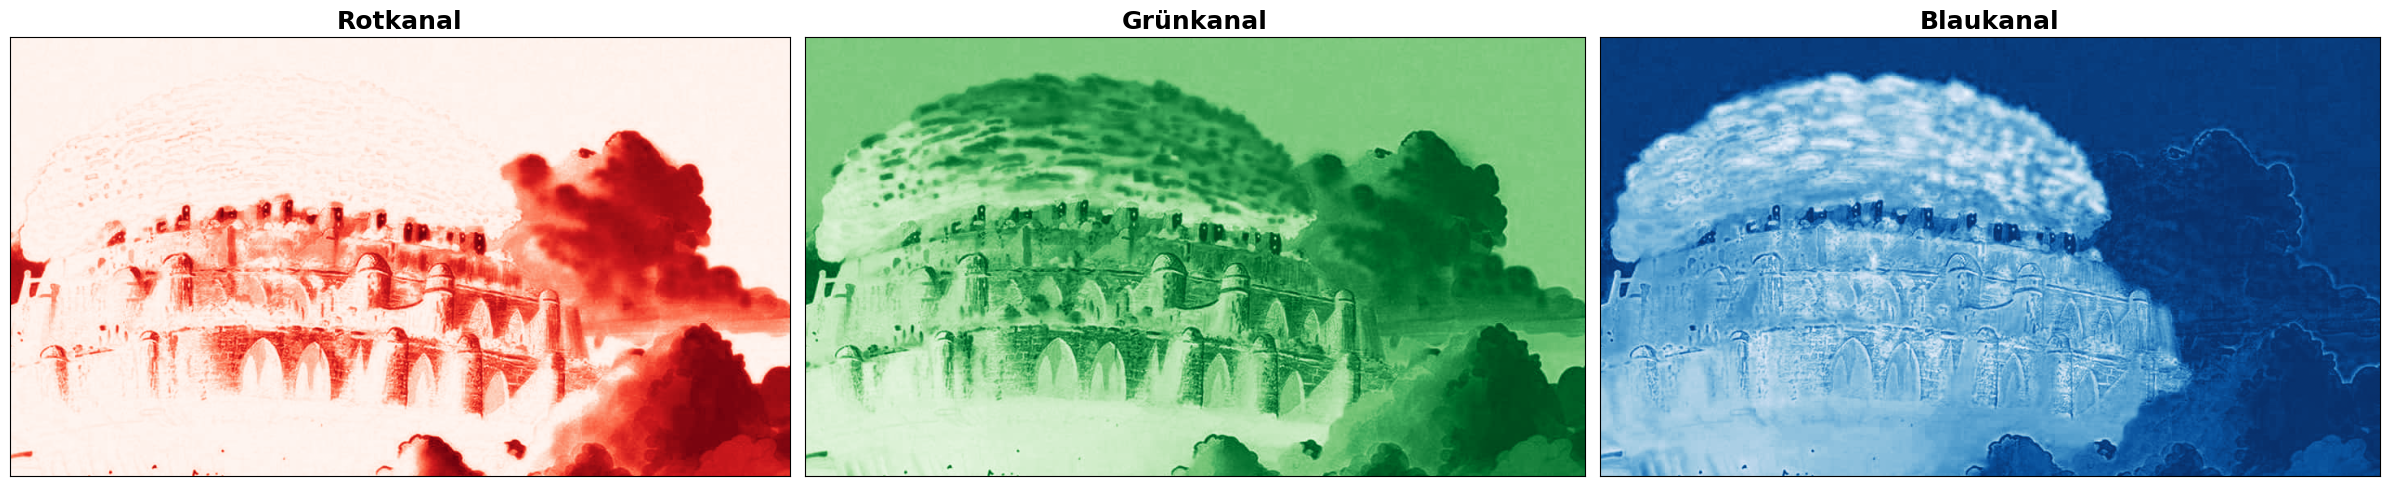

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # alle Bilder in eine figure nebeneinander

axes[0].imshow(img_R, cmap="Reds", vmin=0, vmax=255) # Colormap die Werte werden von 0 bis 255 gemappt
axes[0].set_title("Rotkanal", fontsize=18, fontweight="bold")

axes[1].imshow(img_G, cmap="Greens", vmin=0, vmax=255) # Colormap die Werte werden von 0 bis 255 gemappt
axes[1].set_title("Grünkanal", fontsize=18, fontweight="bold")

axes[2].imshow(img_B, cmap="Blues", vmin=0, vmax=255) # Colormap die Werte werden von 0 bis 255 gemappt
axes[2].set_title("Blaukanal", fontsize=18, fontweight="bold")

# Axenbeschriftung ausblenden
for ax in axes:
    ax.set_xticks([])  # x-Achsen-Beschriftung aus
    ax.set_yticks([])  # y-Achsen-Beschriftung aus

plt.tight_layout()
plt.show()

In dieser Darstellung verwendet die Funktion `imshow()` die Parameter `cmap`, `vmin` und `vmax`, um die Intensitätswerte der Bildpunkte auf eine Farbskala abzubilden.  
Konkret bedeutet dies:

- **`cmap`** legt eine Colormap (z. B. `"Reds"`, `"Greens"` oder `"Blues"`) fest, über die die Datenwerte farblich dargestellt werden.  
  [Dokumentation: matplotlib.org](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)

- **`vmin`** und **`vmax`** bestimmen den Wertebereich der Daten, der auf die vollständige Farbskala abgebildet wird.  
  Werte ≤ `vmin` werden der untersten Farbe der Colormap zugeordnet, Werte ≥ `vmax` der obersten Farbe.  
  [Weitere Erklärung auf StackOverflow](https://stackoverflow.com/questions/31232733/vmin-vmax-algorithm-matplotlib)

- Wird `vmin` und `vmax` nicht explizit angegeben, verwendet Matplotlib standardmäßig die Minimal- und Maximalwerte des Arrays und normiert diese auf den Bereich [0, 1].  
  [Matplotlib Colormap Norms](https://matplotlib.org/stable/users/explain/colors/colormapnorms.html)

- Bei einer Angabe von `vmin=0` und `vmax=255` entspricht der Datenwert 0 der dunkelsten Farbe der Colormap und der Wert 255 der hellsten Farbe (z. B. Weiß oder das obere Ende der Farbskala).

Es kann daher vorkommen, dass Pixel ohne Farbanteil (Wert 0) als weiß dargestellt werden, abhängig von der gewählten Colormap und deren Skalierung.

<br>
Um im nächsten Schritt eine Schwarz-Weiß-Darstellung des Bildes zu erzeugen, wird das ursprüngliche RGB-Bild in eine Graustufenvariante umgewandelt.  
Dabei wird die sogenannte **Luminanz** (Helligkeitsinformation) berechnet, welche die Helligkeitswahrnehmung des menschlichen Auges berücksichtigt.

Die Luminanz wird wie folgt berechnet:\
Y = 0.299 · R + 0.587 · G + 0.114 · B


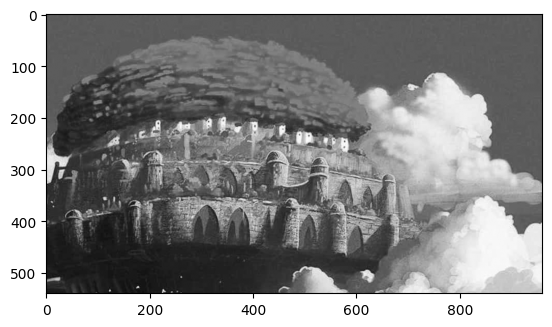

In [ ]:
# Weighted sum according to human perception (ITU-R BT.601 standard)
gray = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

plt.imshow(gray, cmap="gray")


Das Bild wurde erfolgreich in seiner Schwarz-Weiß-Darstellung erzeugt und dargestellt.<br>

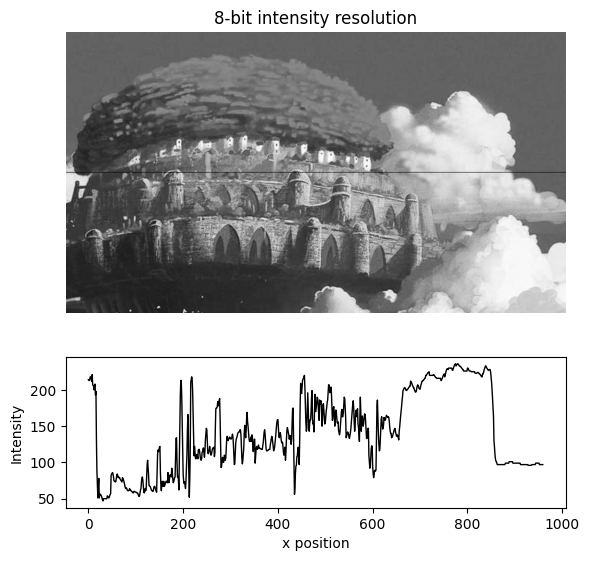

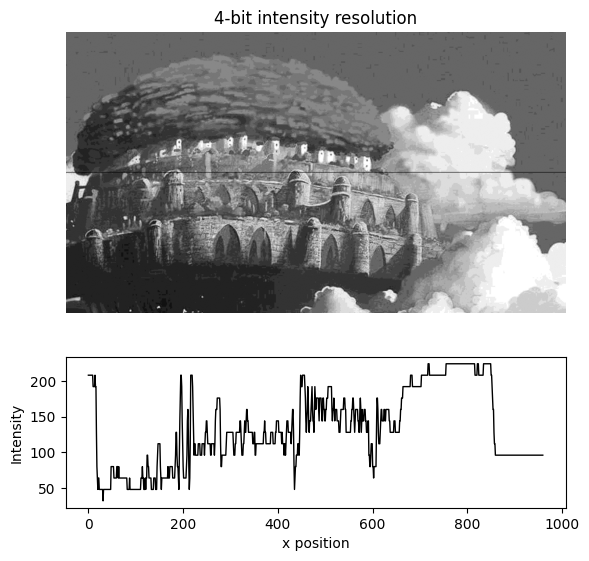

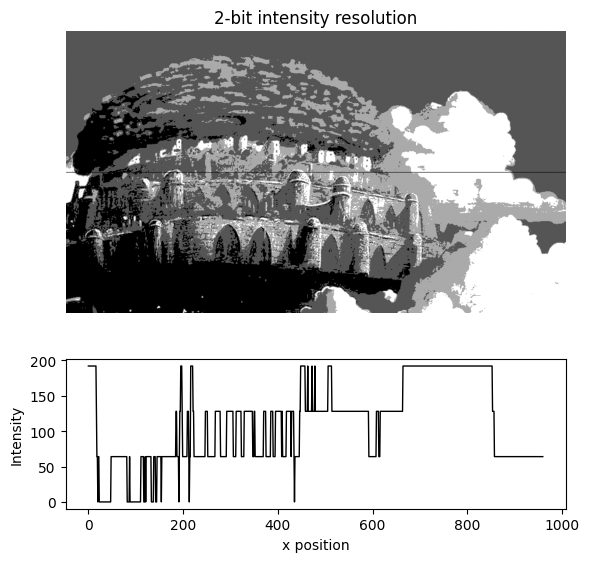

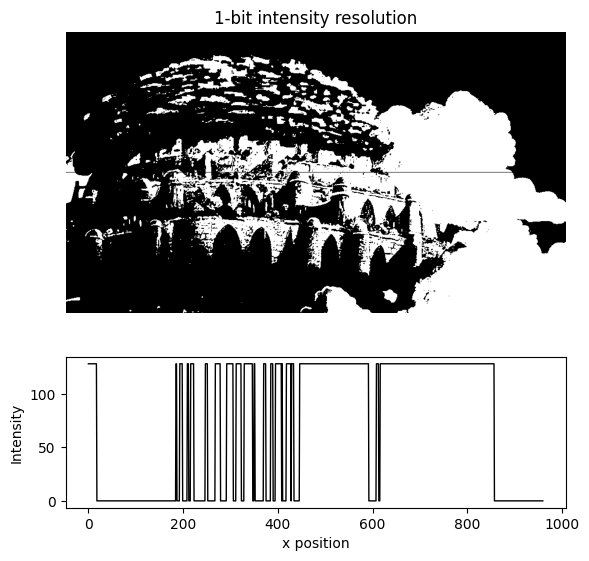

In [137]:
gray_orig = cv2.cvtColor(img_quarter, cv2.COLOR_RGB2GRAY).astype(np.float32)
h, w = gray_orig.shape
for k in [8, 4, 2, 1]:
    levels = 2**k
    gray_k = (np.floor(gray_orig / 256 * levels) * (256 / levels)).astype(np.uint8)
    
    sample = gray_k[h // 2, :].copy()
    gray_k[h // 2, :] = 0 # black center line

    fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6,6), gridspec_kw={"height_ratios": [2.5,1]}
    )

    ax1.imshow(gray_k, cmap="gray")
    ax1.set_title(f'{k}-bit intensity resolution')
    ax1.axis("off")
    ax2.plot(sample, color="black", lw=1)
    ax2.set_ylabel("Intensity")
    ax2.set_xlabel("x position")
    plt.tight_layout()
    plt.show()